# Point Anomaly Tools — Usage Demo

Interactive demo for all tools in `agents/point/tools/`.
Each tool is validated on synthesized data: basic usage, sensitivity, direction, and `run_tool()`.

| Tool | File | Detection style |
|---|---|---|
| ARIMA | `arima.py` | Novelty — forecast prediction interval |
| KDE   | `kde.py`   | Outlier / novelty — kernel density threshold |

---

## Setup

In [3]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 19.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys, pathlib

# Walk up from CWD until we find the directory that contains 'agents/'.
# VS Code Jupyter does not always set CWD to the notebook folder.
_root = pathlib.Path().resolve()
while not (_root / "agents").exists():
    if _root == _root.parent:
        raise RuntimeError("Cannot find project root — no 'agents/' directory found walking up from CWD.")
    _root = _root.parent

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

print(f"Project root: {_root}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agents.point.tools.arima import (
    ARIMAAnomalyDetector,
    TOOL_SCHEMA as ARIMA_SCHEMA,
    run_tool as arima_run_tool,
)
from agents.point.tools.kde import (
    KDEAnomalyDetector,
    TOOL_SCHEMA as KDE_SCHEMA,
    run_tool as kde_run_tool,
)

RNG = np.random.default_rng(42)

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Project root: /Users/injure21/Documents/GitHub/Generative-AI/Agent/Case_Study/anomaly_detection_agent


/Users/injure21/Documents/GitHub/Generative-AI/Agent/Case_Study/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Shared helper: plot detection result ───────────────────────────────────────

def plot_result(result: pd.DataFrame, split_idx: int, title: str = ""):
    """
    Plot the full series with:
      - training window (blue line)
      - test horizon: actual values (orange dots) vs prediction interval (shaded)
      - anomaly flags (red circles)
    """
    n_train = len(result) - split_idx
    train   = result.iloc[:n_train]
    test    = result.iloc[n_train:]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4),
                             gridspec_kw={"width_ratios": [3, 1]})

    # ── Left: full series view ──────────────────────────────────────
    ax = axes[0]
    ax.plot(train["timestamp"], train["value"],
            color="steelblue", linewidth=1.2, label="Train (history)")
    ax.scatter(test["timestamp"], test["value"],
               color="darkorange", s=30, zorder=3, label="Test (held-out actuals)")

    # Highlight anomalies
    anomalies = test[test["is_anomaly"]]
    if not anomalies.empty:
        ax.scatter(anomalies["timestamp"], anomalies["value"],
                   s=120, facecolors="none", edgecolors="red",
                   linewidths=1.8, zorder=4, label=f"Anomaly ({len(anomalies)})")

    # Dividing line between train and test
    ax.axvline(test["timestamp"].iloc[0], color="grey",
               linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(title or "ARIMA Anomaly Detection")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend(fontsize=9)

    # ── Right: zoom into test horizon ──────────────────────────────
    ax2 = axes[1]
    ax2.scatter(range(split_idx), test["value"],
                color="darkorange", s=30, label="Actual")
    if not anomalies.empty:
        idx = [i for i, r in enumerate(test.itertuples()) if r.is_anomaly]
        ax2.scatter(idx, anomalies["value"],
                    s=120, facecolors="none", edgecolors="red",
                    linewidths=1.8, zorder=4)
    ax2.set_title(f"Test horizon (last {split_idx} pts)")
    ax2.set_xlabel("Step in horizon")
    ax2.set_ylabel("Value")

    plt.tight_layout()
    plt.show()

    # ── Summary table ───────────────────────────────────────────────
    flagged = test[test["is_anomaly"]][["timestamp", "value", "anomaly_score", "anomaly_reason"]]
    if flagged.empty:
        print("No anomalies detected in the test horizon.")
    else:
        print(f"{len(flagged)} anomaly/anomalies detected:\n")
        display(flagged.reset_index(drop=True))

---
## 1 — Stationary series with injected spike

A clean Gaussian series (mean=10, std=1) with one large spike injected
at position -5 from the end (inside the test horizon).

In [3]:
SPLIT_IDX = 24

# Synthesize: 200 hourly points, stationary Gaussian
values = RNG.normal(loc=10.0, scale=1.0, size=200)
values[-5] = 45.0          # spike inside the test horizon

timestamps = pd.date_range("2024-01-01", periods=200, freq="h")
df_stationary = pd.DataFrame({"timestamp": timestamps, "value": values})

df_stationary.tail(30)

,timestamp,value
170,2024-01-08 02:00:00,9.345212
171,2024-01-08 03:00:00,10.446072
172,2024-01-08 04:00:00,9.545017
173,2024-01-08 05:00:00,8.774394
174,2024-01-08 06:00:00,8.722062
175,2024-01-08 07:00:00,10.172588
176,2024-01-08 08:00:00,11.579091
177,2024-01-08 09:00:00,10.159992
178,2024-01-08 10:00:00,9.881362
179,2024-01-08 11:00:00,10.285826


In [ ]:
detector = ARIMAAnomalyDetector(
    series_df=df_stationary,
    time_col="timestamp",
    value_col="value",
    split_idx=SPLIT_IDX,
    season_length=24,
    freq="h",
    sensitivity="medium",       # 95% prediction interval
    anomaly_direction="both",
)

result_stationary = detector.run()
result_stationary[["timestamp", "value", "is_anomaly", "anomaly_score", "anomaly_reason"]].tail(30)

In [ ]:
plot_result(result_stationary, SPLIT_IDX, title="Stationary series — spike at step -5 of horizon")

---
## 2 — Trending + seasonal series

Daily seasonality (period=24) with a linear upward trend.
Two anomalies injected in the test horizon: one spike, one dip.

In [ ]:
n = 240      # 10 days of hourly data
t = np.arange(n)

values_seasonal = (
    0.03 * t                                       # upward trend
    + 5.0 * np.sin(2 * np.pi * t / 24)            # daily cycle
    + RNG.normal(loc=0.0, scale=0.8, size=n)       # noise
)

# Inject anomalies inside the test horizon (last 24 points)
values_seasonal[-10] += 20.0    # spike
values_seasonal[-3]  -= 18.0    # dip

timestamps_s = pd.date_range("2024-01-01", periods=n, freq="h")
df_seasonal = pd.DataFrame({"timestamp": timestamps_s, "value": values_seasonal})

# Quick look at the raw series
plt.figure(figsize=(14, 3))
plt.plot(df_seasonal["timestamp"], df_seasonal["value"], linewidth=0.9)
plt.title("Synthesized: trend + daily seasonality + injected anomalies")
plt.tight_layout()
plt.show()

In [ ]:
result_seasonal = ARIMAAnomalyDetector(
    series_df=df_seasonal,
    time_col="timestamp",
    value_col="value",
    split_idx=24,
    season_length=24,
    freq="h",
    sensitivity="medium",
    anomaly_direction="both",
).run()

plot_result(result_seasonal, 24, title="Trend + seasonal series — spike and dip in horizon")

---
## 3 — Effect of `sensitivity`

Same series, same spike — compare how many points are flagged across the three sensitivity levels.

| Sensitivity | Interval width | Expectation |
|---|---|---|
| `low`    | 99% | Only the most extreme outlier flagged |
| `medium` | 95% | Standard — default |
| `high`   | 90% | Flags mild deviations too |

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, sensitivity in zip(axes, ["low", "medium", "high"]):
    result = ARIMAAnomalyDetector(
        series_df=df_stationary,
        time_col="timestamp",
        value_col="value",
        split_idx=SPLIT_IDX,
        season_length=24,
        freq="h",
        sensitivity=sensitivity,
        anomaly_direction="both",
    ).run()

    test = result.iloc[-SPLIT_IDX:]
    n_flags = test["is_anomaly"].sum()

    ax.scatter(range(SPLIT_IDX), test["value"], s=25, color="darkorange", label="Actual")
    anomalies = test[test["is_anomaly"]]
    if not anomalies.empty:
        ax.scatter(
            [i for i, r in enumerate(test.itertuples()) if r.is_anomaly],
            anomalies["value"],
            s=120, facecolors="none", edgecolors="red", linewidths=1.8, zorder=4,
        )
    ax.set_title(f"sensitivity='{sensitivity}'  ({n_flags} flag{'s' if n_flags != 1 else ''})")
    ax.set_xlabel("Step in horizon")

axes[0].set_ylabel("Value")
plt.suptitle("Sensitivity comparison — test horizon only", y=1.02)
plt.tight_layout()
plt.show()

---
## 4 — Effect of `anomaly_direction`

A series with both a spike (+35) and a dip (−15) in the horizon.
- `'both'` → flags both
- `'upper'` → only the spike
- `'lower'` → only the dip

In [ ]:
values_both = RNG.normal(loc=10.0, scale=1.0, size=200)
values_both[-8]  = 45.0    # spike
values_both[-3]  = -15.0   # dip

df_both = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=200, freq="h"),
    "value": values_both,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, direction in zip(axes, ["both", "upper", "lower"]):
    result = ARIMAAnomalyDetector(
        series_df=df_both,
        time_col="timestamp",
        value_col="value",
        split_idx=SPLIT_IDX,
        season_length=24,
        freq="h",
        sensitivity="medium",
        anomaly_direction=direction,
    ).run()

    test = result.iloc[-SPLIT_IDX:]
    n_flags = test["is_anomaly"].sum()

    ax.scatter(range(SPLIT_IDX), test["value"], s=25, color="darkorange")
    anomalies = test[test["is_anomaly"]]
    if not anomalies.empty:
        ax.scatter(
            [i for i, r in enumerate(test.itertuples()) if r.is_anomaly],
            anomalies["value"],
            s=130, facecolors="none", edgecolors="red", linewidths=1.8, zorder=4,
        )
    ax.set_title(f"direction='{direction}'  ({n_flags} flags)")
    ax.set_xlabel("Step in horizon")
    ax.axhline(10, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.6)

axes[0].set_ylabel("Value")
plt.suptitle("anomaly_direction comparison — test horizon only", y=1.02)
plt.tight_layout()
plt.show()

---
## 5 — Using `run_tool()` (agent executor interface)

This is the function the agent's tool-dispatch loop calls.  
The DataFrame stays in Python memory (agent state); only scalar parameters travel through `tool_input`.

In [ ]:
# Simulates what the agent's dispatch loop does when the model emits a tool_use block:
#
#   {
#     "type": "tool_use",
#     "name": "arima_anomaly_detector",
#     "input": { "time_col": "timestamp", "value_col": "value", "split_idx": 24, ... }
#   }

tool_input = {
    "time_col":          "timestamp",
    "value_col":         "value",
    "split_idx":         24,
    "season_length":     24,
    "freq":              "h",
    "sensitivity":       "medium",
    "anomaly_direction": "both",
}

tool_result = run_tool(series_df=df_stationary, tool_input=tool_input)

print(f"anomaly_count  : {tool_result['anomaly_count']}")
print(f"total_points   : {tool_result['total_points']}")
print(f"horizon_points : {tool_result['horizon_points']}")
print(f"records (last 5 rows):")

# Show last 5 records (the end of the test horizon)
import pprint
pprint.pprint(tool_result["records"][-5:])

In [ ]:
# TOOL_SCHEMA — what the agent passes to client.messages.create(tools=[TOOL_SCHEMA])
import json
print(json.dumps(TOOL_SCHEMA, indent=2))

---
---
# Part 2 — KDEAnomalyDetector (`tools/kde.py`)

Fits a **Gaussian KDE** on training data and flags points whose density falls
below the 1st-percentile training threshold AND whose value is in the specified tail.

**Two modes:**
| Mode | `split_idx` | Training rows flaggable? | Use when |
|---|---|---|---|
| Outlier | `0` | Yes | Global outlier search on a stationary series |
| Novelty | `N` | No | Monitor recent window, same as ARIMA |

**Anomaly score:** `density_threshold / point_density` — values > 1 mean the point
is outside the density threshold (consistent with ARIMA's score convention).

---
## KDE-1 — Outlier mode: stationary Gaussian with injected spike

`split_idx=0` → trains and scores on the full series.
Both training and test points can be flagged.

In [4]:
values_kde = RNG.normal(loc=10.0, scale=1.0, size=200)
values_kde[50]  = 45.0    # spike in training window
values_kde[150] = -15.0   # dip in training window

df_kde = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=200, freq="h"),
    "value": values_kde,
})

result_kde_outlier = KDEAnomalyDetector(
    series_df=df_kde,
    time_col="timestamp",
    value_col="value",
    split_idx=0,            # outlier mode
    bandwidth=0.5,
    sensitivity="medium",
    anomaly_direction="both",
).run()

# Full result
flagged = result_kde_outlier[result_kde_outlier["is_anomaly"]]
print(f"Total flagged: {len(flagged)} / {len(result_kde_outlier)}\n")
display(flagged[["timestamp", "value", "is_anomaly", "anomaly_score", "anomaly_reason"]].reset_index(drop=True))

Total flagged: 2 / 200



,timestamp,value,is_anomaly,anomaly_score,anomaly_reason
0,2024-01-03 02:00:00,45.0,True,3.597309,Value (45.0) is unusually high (above 97th-per...
1,2024-01-07 06:00:00,-15.0,True,3.597309,Value (-15.0) is unusually low (below 97th-per...


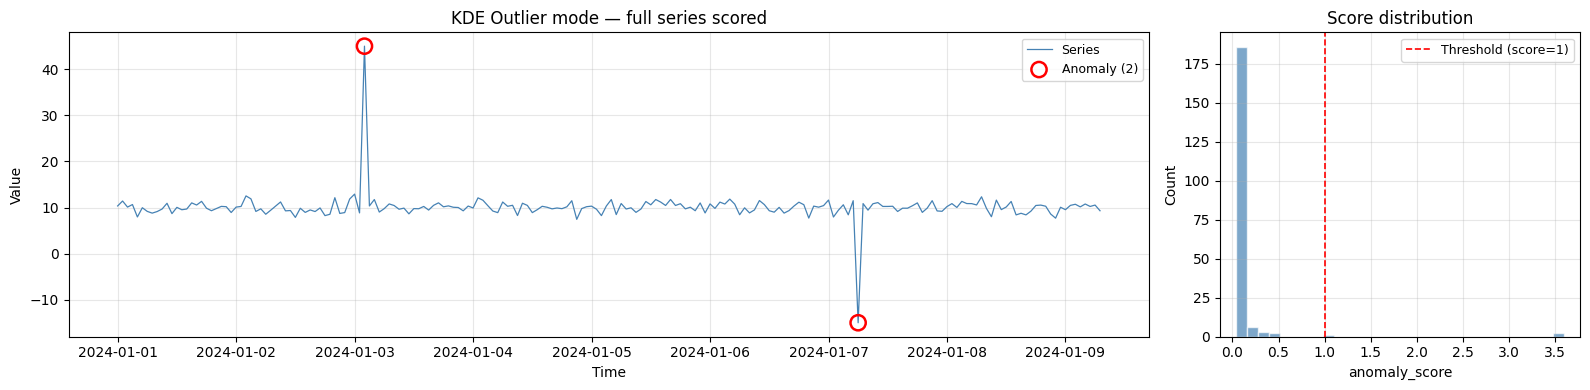

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0]
ax.plot(df_kde["timestamp"], df_kde["value"], color="steelblue", linewidth=0.9, label="Series")
anomalies = result_kde_outlier[result_kde_outlier["is_anomaly"]]
if not anomalies.empty:
    ax.scatter(anomalies["timestamp"], anomalies["value"],
               s=120, facecolors="none", edgecolors="red", linewidths=1.8,
               zorder=4, label=f"Anomaly ({len(anomalies)})")
ax.set_title("KDE Outlier mode — full series scored")
ax.set_xlabel("Time"); ax.set_ylabel("Value"); ax.legend(fontsize=9)

# Right: score distribution
ax2 = axes[1]
scores = result_kde_outlier["anomaly_score"].dropna()
ax2.hist(scores, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
ax2.axvline(1.0, color="red", linestyle="--", linewidth=1.2, label="Threshold (score=1)")
ax2.set_title("Score distribution")
ax2.set_xlabel("anomaly_score"); ax2.set_ylabel("Count"); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

---
## KDE-2 — Novelty mode: score only the last N points

`split_idx=24` → train on rows 0–175, score rows 176–199.
Training rows always have `is_anomaly=False` and `anomaly_score=NaN` — same as ARIMA.

In [6]:
values_nov = RNG.normal(loc=10.0, scale=1.0, size=200)
values_nov[-5] = 45.0    # spike in test horizon only

df_novelty = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=200, freq="h"),
    "value": values_nov,
})

result_kde_novelty = KDEAnomalyDetector(
    series_df=df_novelty,
    time_col="timestamp",
    value_col="value",
    split_idx=24,
    bandwidth=0.5,
    sensitivity="medium",
    anomaly_direction="both",
).run()

# Confirm training rows are clean
n_train = 200 - 24
print(f"Training rows flagged : {result_kde_novelty.iloc[:n_train]['is_anomaly'].sum()}  (expected 0)")
print(f"Test rows flagged     : {result_kde_novelty.iloc[n_train:]['is_anomaly'].sum()}")
print()
display(result_kde_novelty.iloc[n_train:][["timestamp","value","is_anomaly","anomaly_score","anomaly_reason"]].reset_index(drop=True))

Training rows flagged : 0  (expected 0)
Test rows flagged     : 1



,timestamp,value,is_anomaly,anomaly_score,anomaly_reason
0,2024-01-08 08:00:00,11.336186,False,0.185305,
1,2024-01-08 09:00:00,11.247950,False,0.167322,
2,2024-01-08 10:00:00,9.747483,False,0.080250,
3,2024-01-08 11:00:00,10.363454,False,0.083480,
4,2024-01-08 12:00:00,7.590078,False,0.736887,
5,2024-01-08 13:00:00,8.843652,False,0.138034,
6,2024-01-08 14:00:00,9.706221,False,0.081104,
7,2024-01-08 15:00:00,8.927867,False,0.128170,
8,2024-01-08 16:00:00,10.714396,False,0.101471,
9,2024-01-08 17:00:00,11.997297,False,0.460257,


---
## KDE-3 — Effect of `sensitivity`

Sensitivity controls the directional value tail threshold:
`low` → 99th percentile, `medium` → 97th, `high` → 95th.

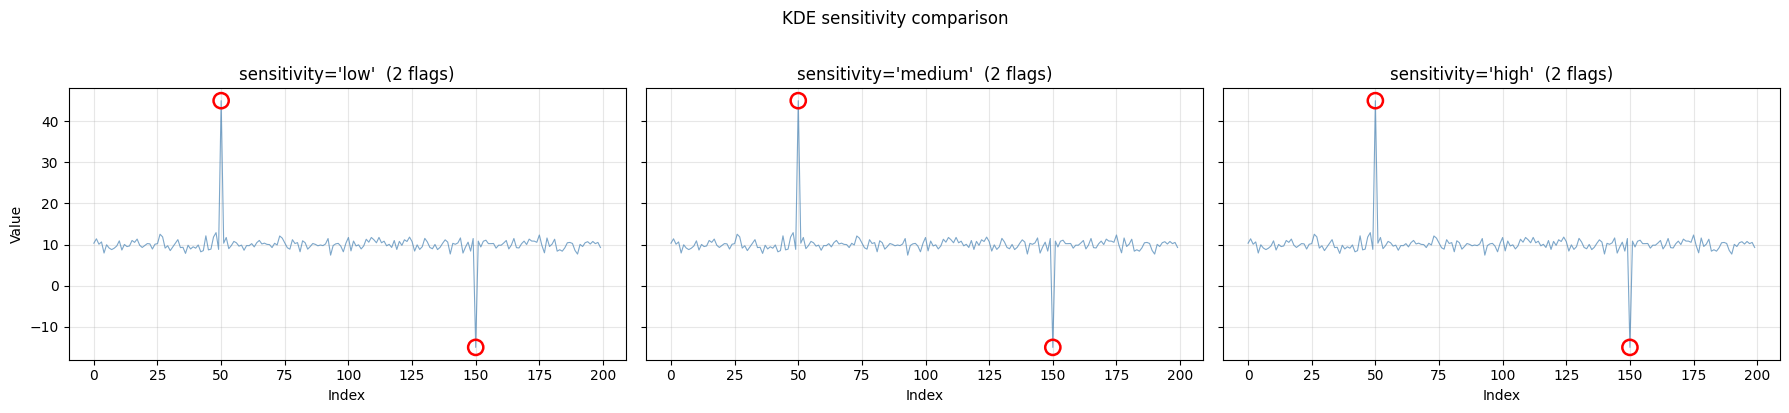

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, sensitivity in zip(axes, ["low", "medium", "high"]):
    result = KDEAnomalyDetector(
        series_df=df_kde,
        time_col="timestamp",
        value_col="value",
        split_idx=0,
        sensitivity=sensitivity,
        anomaly_direction="both",
    ).run()
    n_flags = result["is_anomaly"].sum()
    ax.plot(range(len(result)), result["value"], color="steelblue", linewidth=0.8, alpha=0.7)
    anomalies = result[result["is_anomaly"]]
    if not anomalies.empty:
        ax.scatter(anomalies.index, anomalies["value"],
                   s=120, facecolors="none", edgecolors="red", linewidths=1.8, zorder=4)
    ax.set_title(f"sensitivity='{sensitivity}'  ({n_flags} flags)")
    ax.set_xlabel("Index")

axes[0].set_ylabel("Value")
plt.suptitle("KDE sensitivity comparison", y=1.02)
plt.tight_layout(); plt.show()